In [1]:
import sys
from pathlib import Path
from pyprojroot import here

sys.path.append(str(here()))

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold
from src.processing import build_pipeline
import lightgbm as lgb
from tqdm.auto import tqdm
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import root_mean_squared_error
from datetime import datetime
import json
import importlib
from src.config import cfg
from src.utils import set_seed
from sklearn.inspection import permutation_importance

In [3]:
import warnings

warnings.filterwarnings("ignore", message="Found unknown categories in columns")

In [4]:
%load_ext autoreload
%autoreload 2


In [5]:
gseed = cfg.general.seed
set_seed(gseed)

In [6]:
train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_all_data = pd.concat(
    [df_train.drop(columns=["SalePrice"]), df_test], axis=0
).reset_index(drop=True)

df_all_data.shape

(2919, 80)

In [7]:
X_train = df_train.drop(columns=["SalePrice"])
y_train = np.log1p(df_train["SalePrice"])
y_binned = pd.qcut(y_train, q=10, labels=False)

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed)

### baseline score

In [8]:
baseline_pipe = build_pipeline(kind="tree_oe&lgbm")

baseline_model = lgb.LGBMRegressor(verbosity=-1, random_state=gseed)

In [9]:
def cv_result(
    model,
    X_train,
    y_train,
    y_strat,
    cv_splitter,
    preprocessor,
    name=None,
    fit_params=None,
    use_early_stopping=False,
    early_stopping_callback=None,
    calculate_importance=False,
    perm_n_repeats=5,
    random_state=gseed,
):
    """
    Universal cv function, but could use LGBM early stopping
    """
    fit_params = fit_params or {}
    model_pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])

    fitted_models = []
    oof_preds_sum = np.zeros(len(X_train), dtype=float)
    oof_counts = np.zeros(len(X_train), dtype=float)

    tr_scores, val_scores = [], []

    fold_importances = []

    splits = list(cv_splitter.split(X_train, y_strat))

    for train_idx, val_idx in tqdm(
        splits, desc=name or "CV folds", unit="fold", leave=False
    ):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        fold_pipe = clone(model_pipe)

        fold_fit_params = fit_params.copy()

        if use_early_stopping:
            fold_preprocessor = clone(preprocessor)
            X_tr_trans = fold_preprocessor.fit_transform(X_tr, y_tr)
            X_val_trans = fold_preprocessor.transform(X_val)

            fold_fit_params["model__eval_X"] = X_val_trans
            fold_fit_params["model__eval_y"] = y_val

            if early_stopping_callback is not None:
                fold_fit_params["model__callbacks"] = [early_stopping_callback]

            fold_pipe.fit(X_tr, y_tr, **fold_fit_params)
        else:
            fold_pipe.fit(X_tr, y_tr, **fold_fit_params)

        if calculate_importance:
            res = permutation_importance(
                fold_pipe,
                X_val,
                y_val,
                scoring="neg_root_mean_squared_error",
                n_repeats=perm_n_repeats,
                random_state=random_state,
                n_jobs=-1,
            )
            fold_importances.append(res.importances_mean)

        fold_preds_tr = fold_pipe.predict(X_tr)
        fold_preds_val = fold_pipe.predict(X_val)

        oof_preds_sum[val_idx] += fold_preds_val
        oof_counts[val_idx] += 1

        fitted_models.append(fold_pipe)

        tr_scores.append(root_mean_squared_error(y_tr, fold_preds_tr))
        val_scores.append(root_mean_squared_error(y_val, fold_preds_val))

    oof_preds = oof_preds_sum / oof_counts
    oof_mse = root_mean_squared_error(y_train, oof_preds)

    metrics = pd.DataFrame(
        [
            {
                "model": name,
                "TRAIN_rmsle_MEAN": np.mean(tr_scores),
                "TRAIN_rmsle_STD": np.std(tr_scores),
                "VAL_rmsle_MEAN": np.mean(val_scores),
                "VAL_rmsle_STD": np.std(val_scores),
                "OOF_rmsle": oof_mse,
            }
        ]
    )

    importance_df = None
    if calculate_importance:
        importance_df = pd.DataFrame(fold_importances, columns=X_train.columns).T
        fold_cols = importance_df.columns.tolist()

        importance_df["importance_mean"] = importance_df[fold_cols].mean(axis=1)
        importance_df["importance_std"] = importance_df[fold_cols].std(axis=1)

        importance_df = importance_df.sort_values(by="importance_mean", ascending=False)

        return fitted_models, oof_preds, metrics, val_scores, importance_df
    return fitted_models, oof_preds, metrics, val_scores

In [54]:
fitted_models, oof_preds, metrics, val_scores1 = cv_result(
    baseline_model, X_train, y_train, y_binned, rskf, baseline_pipe, "baseline_model"
)
metrics

baseline_model:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline_model,0.040354,0.000925,0.126783,0.014888,0.123936


In [10]:
def log_fe_experiment(metrics: dict, note: str = ""):
    log_dir = Path(cfg.paths.logs)
    log_file_path = log_dir / "fe_experiments.log"

    log_dir.mkdir(parents=True, exist_ok=True)

    record = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "metrics": metrics,
        "note": note,
    }

    with open(log_file_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, default=str, ensure_ascii=False) + "\n")

In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(metrics=metrics_dict, note="baseline model")


### early stopping baseline

На данной модели будут валидироваться все стратегии

In [11]:
lgbm_search_model = lgb.LGBMRegressor(
    n_estimators=3000, learning_rate=0.05, verbosity=-1, random_state=gseed
)

es_callback = lgb.early_stopping(stopping_rounds=100, verbose=False)


In [59]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=baseline_pipe,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.042563,0.018836,0.124476,0.014221,0.122015


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(metrics=metrics_dict, note="baseline with early stopping")

### clean data
данные без багов и выбросов

In [12]:
def fix_data_bugs(df):
    df = df.copy()

    idx_2126 = 2126
    detchd_mask = df["GarageType"] == "Detchd"

    for col in ["GarageQual", "GarageCond"]:
        df.loc[idx_2126, col] = df.loc[detchd_mask, col].mode()[0]

    df.loc[idx_2126, "GarageFinish"] = df.loc[detchd_mask, "GarageFinish"].mode()[0]
    df.loc[idx_2126, "GarageYrBlt"] = df.loc[idx_2126, "YearBuilt"]

    idx_2576 = 2576
    df.loc[idx_2576, "GarageType"] = "None"
    for col in ["GarageQual", "GarageFinish", "GarageCond"]:
        df.loc[idx_2576, col] = "None"
    df.loc[idx_2576, ["GarageYrBlt", "GarageCars", "GarageArea"]] = 0

    idx_exposure_missing = [948, 1487, 2348]
    idx_cond_missing = [2040, 2185, 2524]
    idx_qual_missing = [2217, 2218]
    idx_fintype2_missing = [332]

    exposure_mode = df.loc[df["TotalBsmtSF"] > 0, "BsmtExposure"].mode()[0]
    df.loc[idx_exposure_missing, "BsmtExposure"] = exposure_mode

    cond_mode = df.loc[df["TotalBsmtSF"] > 0, "BsmtCond"].mode()[0]
    df.loc[idx_cond_missing, "BsmtCond"] = cond_mode

    qual_mode = df.loc[df["TotalBsmtSF"] > 0, "BsmtQual"].mode()[0]
    df.loc[idx_qual_missing, "BsmtQual"] = qual_mode

    fintype2_mode = df.loc[df["BsmtFinSF2"] > 0, "BsmtFinType2"].mode()[0]
    df.loc[idx_fintype2_missing, "BsmtFinType2"] = fintype2_mode

    df.loc[2592, "GarageYrBlt"] = 2007

    return df


def remove_train_outliers(df_train):
    outlier_mask = (df_train["GrLivArea"] > 4000) & (df_train["SalePrice"] < 300000)
    return df_train[~outlier_mask].reset_index(drop=True)

In [13]:
df_all_data = fix_data_bugs(df_all_data)
df_all_data.shape

(2919, 80)

In [14]:
df_all_data = df_all_data.drop(columns=["Id"])

In [15]:
X_train_raw, X_test = df_all_data[: df_train.shape[0]], df_all_data[df_train.shape[0] :]
X_train_raw.shape

(1460, 79)

In [16]:
df_raw = remove_train_outliers(pd.concat([X_train_raw, df_train["SalePrice"]], axis=1))

In [17]:
X_train = df_raw.drop(columns=["SalePrice"])
y_train = np.log1p(df_raw["SalePrice"])
y_binned = pd.qcut(y_train, q=10, labels=False)

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed)

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=baseline_pipe,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# чистые данные полезны

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.040583,0.014454,0.120983,0.013182,0.11876


In [72]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(metrics=metrics_dict, note="BWES + clean data")

### lot frontage imputing strategy

In [17]:
from src.tests.tests1 import advanced

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# продвинутая версия лучше

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.039861,0.014456,0.120734,0.0133,0.118564


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict, note="BWES + clean data + new lot frontage strategy"
)

### new features
MoSold_sin & MoSold_cos

In [18]:
from src.tests.tests1 import advanced

In [20]:
"MoSold_cos" in advanced.fit_transform(X_train, y_train).columns

True

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# фичи месяцев полезны

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.11847


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures",
)

### new features
["HouseAge", "RemodAge", "GarageAge", "IsRemodeled", "IsNewHouse"]

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

In [41]:
"HouseAge" in advanced.fit_transform(X_train, y_train).columns

True

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# фичи годов ухудшили результат

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.038167,0.013968,0.120806,0.01298,0.118629


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + YearFeatures",
)

### new features
["TotalSF","TotalBathrooms","TotalPorchSF","AreaPerRoom","LivingAreaRatio"]

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

In [ ]:
"TotalSF" in advanced.fit_transform(X_train, y_train).columns

True

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# фичи площади ухудшили скор

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.045304,0.015931,0.121676,0.012772,0.11973


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + AreaFeatures",
)

### new features
["HasPool","HasGarage","HasBsmt","HasFireplace","Has2ndFloor"]


In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

In [ ]:
"Has2ndFloor" in advanced.fit_transform(X_train, y_train).columns

True

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# фичи-флаги бесполезны

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.11847


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + Flags",
)

### new feature
only TotalSF

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced


In [ ]:
"TotalSF" in advanced.fit_transform(X_train, y_train).columns


True

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# плохая фича


baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.045175,0.016292,0.122097,0.013214,0.120179


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + TotalSF",
)

### new features
["OverallQual", "OverallCond", "MoSold", "YrSold"] - в категориальные

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced


In [ ]:
"OverallQual" in tests1.ohe_columns  # advanced.fit_transform(X_train, y_train).columns

True

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# в виде числовых фичей были полезнее


baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.039116,0.016542,0.122895,0.013467,0.120651


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + num2cat",
)

### new features
new age features instead of old ones

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

In [ ]:
"YrSold" in tests1.num_columns  # advanced.fit_transform(X_train, y_train).columns

False

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# старые фичи возраста были лучше


baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.042537,0.01168,0.121148,0.013491,0.11909


In [92]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + AgeNewVsLegacy",
)

### new feature
try AreaPerCar



In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

In [ ]:
"AreaPerCar" in advanced.fit_transform(X_train, y_train).columns

True

In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# не очень полезная фича


baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.04048,0.012978,0.120832,0.013352,0.118716


In [105]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + AreaPerCar",
)

### check experiments

In [106]:
from IPython.display import display

log_file_path = Path(cfg.paths.logs) / "fe_experiments.log"
df = pd.read_json(log_file_path, lines=True)

normalized_data = pd.json_normalize(df["metrics"])
df = pd.concat([df.drop(columns=["metrics"]), normalized_data], axis=1)


with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(df.sort_values(by=["OOF_rmsle"], ascending=True))


,timestamp,note,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
7,2026-09-17 23:18:09,BWES + clean data + new lot frontage strategy + MonthFeatures + Flags,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.118470
4,2026-09-17 18:35:15,BWES + clean data + new lot frontage strategy + MonthFeatures,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.118470
3,2026-09-17 18:16:37,BWES + clean data + new lot frontage strategy,baseline with early stopping,0.039861,0.014456,0.120734,0.013300,0.118564
5,2026-09-17 23:02:59,BWES + clean data + new lot frontage strategy + MonthFeatures + YearFeatures,baseline with early stopping,0.038167,0.013968,0.120806,0.012980,0.118629
11,2026-09-18 00:07:50,BWES + clean data + new lot frontage strategy + MonthFeatures + AreaPerCar,baseline with early stopping,0.040480,0.012978,0.120832,0.013352,0.118716
2,2026-09-17 17:55:42,BWES + clean data,baseline with early stopping,0.040583,0.014454,0.120983,0.013182,0.118760
10,2026-09-17 23:51:52,BWES + clean data + new lot frontage strategy + MonthFeatures + AgeNewVsLegacy,baseline with early stopping,0.042537,0.011680,0.121148,0.013491,0.119090
6,2026-09-17 23:08:35,BWES + clean data + new lot frontage strategy + MonthFeatures + AreaFeatures,baseline with early stopping,0.045304,0.015931,0.121676,0.012772,0.119730
8,2026-09-17 23:22:56,BWES + clean data + new lot frontage strategy + MonthFeatures + TotalSF,baseline with early stopping,0.045175,0.016292,0.122097,0.013214,0.120179
9,2026-09-17 23:31:55,BWES + clean data + new lot frontage strategy + MonthFeatures + num2cat,baseline with early stopping,0.039116,0.016542,0.122895,0.013467,0.120651


### Итог:
Лучшей связкой является: BWES + clean data + new lot frontage strategy + MonthFeatures

### corr

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced


In [98]:
data_processed = advanced.fit_transform(X_train)

In [ ]:
corr_matrix = data_processed.select_dtypes(include=["int", "float"]).corr()
corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.abs().sort_values(ascending=False)

strong_pairs = sorted_pairs[sorted_pairs < 1.0].drop_duplicates()

print(strong_pairs.head(30))

GarageCond    GarageQual      0.959168
              GarageYrBlt     0.949406
GarageYrBlt   GarageQual      0.946624
GarageArea    GarageCars      0.887304
BsmtFinType2  BsmtFinSF2      0.794624
BsmtFinSF1    BsmtFinType1    0.721132
KitchenQual   ExterQual       0.713812
BsmtFullBath  BsmtFinSF1      0.658507
BsmtQual      BsmtCond        0.634737
GarageYrBlt   GarageCars      0.598211
BsmtFinType1  BsmtFullBath    0.588402
GarageCars    GarageFinish    0.579175
BsmtQual      TotalBsmtSF     0.577795
GarageCars    GarageQual      0.576854
GarageCond    GarageCars      0.568628
GarageYrBlt   GarageArea      0.563999
ExterQual     BsmtQual        0.563115
GarageArea    GarageQual      0.562323
              GarageCond      0.550536
ExterQual     GarageCars      0.525960
BsmtUnfSF     BsmtFinSF1      0.522303
HeatingQC     ExterQual       0.519683
ExterQual     GarageFinish    0.517046
GarageFinish  GarageArea      0.515014
GarageCars    KitchenQual     0.509042
BsmtQual      KitchenQual

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# не очень полезная фича


baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.11847


In [115]:
importances = []

for model in models:
    estimator = model.named_steps["model"]
    importances.append(
        pd.Series(estimator.feature_importances_, index=estimator.feature_name_)
    )

importance_df = pd.concat(importances, axis=1)
mean_importance = importance_df.mean(axis=1).sort_values(ascending=False)
std_importance = importance_df.std(axis=1)

result = pd.DataFrame(
    {
        "mean_importance": mean_importance,
        "std_importance": std_importance,
    }
).sort_values("mean_importance", ascending=False)

result

,mean_importance,std_importance
GrLivArea,611.22,545.380425
LotArea,518.50,783.185391
1stFlrSF,468.06,716.559792
TotalBsmtSF,467.60,541.604042
GarageArea,417.22,664.494139
...,...,...
Condition2,0.00,0.000000
RoofMatl,0.00,0.000000
PoolQC,0.00,0.000000
PoolArea,0.00,0.000000


In [ ]:
result[result["mean_importance"] == 0].index.to_list()

(75, 2)


['Condition2', 'RoofMatl', 'PoolQC', 'PoolArea', 'Street']

In [119]:
result[result["mean_importance"] > 0]

,mean_importance,std_importance
GrLivArea,611.22,545.380425
LotArea,518.50,783.185391
1stFlrSF,468.06,716.559792
TotalBsmtSF,467.60,541.604042
GarageArea,417.22,664.494139
...,...,...
MiscFeature,0.96,2.099174
MiscVal,0.88,2.246448
BldgType,0.82,3.514924
Heating,0.60,3.030458


In [110]:
zero_importance = result[result["mean_importance"] == 0].index.tolist()
print(len(zero_importance))
print(zero_importance)

for col in zero_importance:
    if col in X_train.columns:
        print(
            col,
            X_train[col].sum()
            if X_train[col].dtype not in ("str", "object")
            else X_train[col].value_counts(),
        )

5
['Condition2', 'RoofMatl', 'PoolQC', 'PoolArea', 'Street']
Condition2 Condition2
Norm      1444
Feedr        6
Artery       2
RRNn         2
PosA         1
PosN         1
RRAn         1
RRAe         1
Name: count, dtype: int64
RoofMatl RoofMatl
CompShg    1433
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
Name: count, dtype: int64
PoolQC PoolQC
Ex    2
Fa    2
Gd    2
Name: count, dtype: int64
PoolArea 3548
Street Street
Pave    1452
Grvl       6
Name: count, dtype: int64


In [112]:
from sklearn.inspection import permutation_importance

perm_importances = []

for model in tqdm(models, desc="Permutation importance"):
    estimator = model.named_steps["model"]

    result = permutation_importance(
        estimator,
        data_processed,
        y_train,
        n_repeats=10,
        random_state=gseed,
        scoring="neg_root_mean_squared_error",
    )
    perm_importances.append(
        pd.Series(result.importances_mean, index=data_processed.columns)
    )

perm_df = pd.concat(perm_importances, axis=1)
perm_mean = perm_df.mean(axis=1).sort_values(ascending=False)
perm_std = perm_df.std(axis=1)

perm_result = pd.DataFrame(
    {
        "mean_importance": perm_mean,
        "std_importance": perm_std,
    }
).sort_values("mean_importance", ascending=False)

perm_result

Permutation importance:   0%|          | 0/50 [00:00<?, ?it/s]

,mean_importance,std_importance
OverallQual,0.125157,0.006727
GrLivArea,0.101645,0.007488
Neighborhood,0.049206,0.005084
TotalBsmtSF,0.027309,0.004107
OverallCond,0.018167,0.003138
...,...,...
Condition2,0.000000,0.000000
RoofMatl,0.000000,0.000000
PoolQC,0.000000,0.000000
PoolArea,0.000000,0.000000


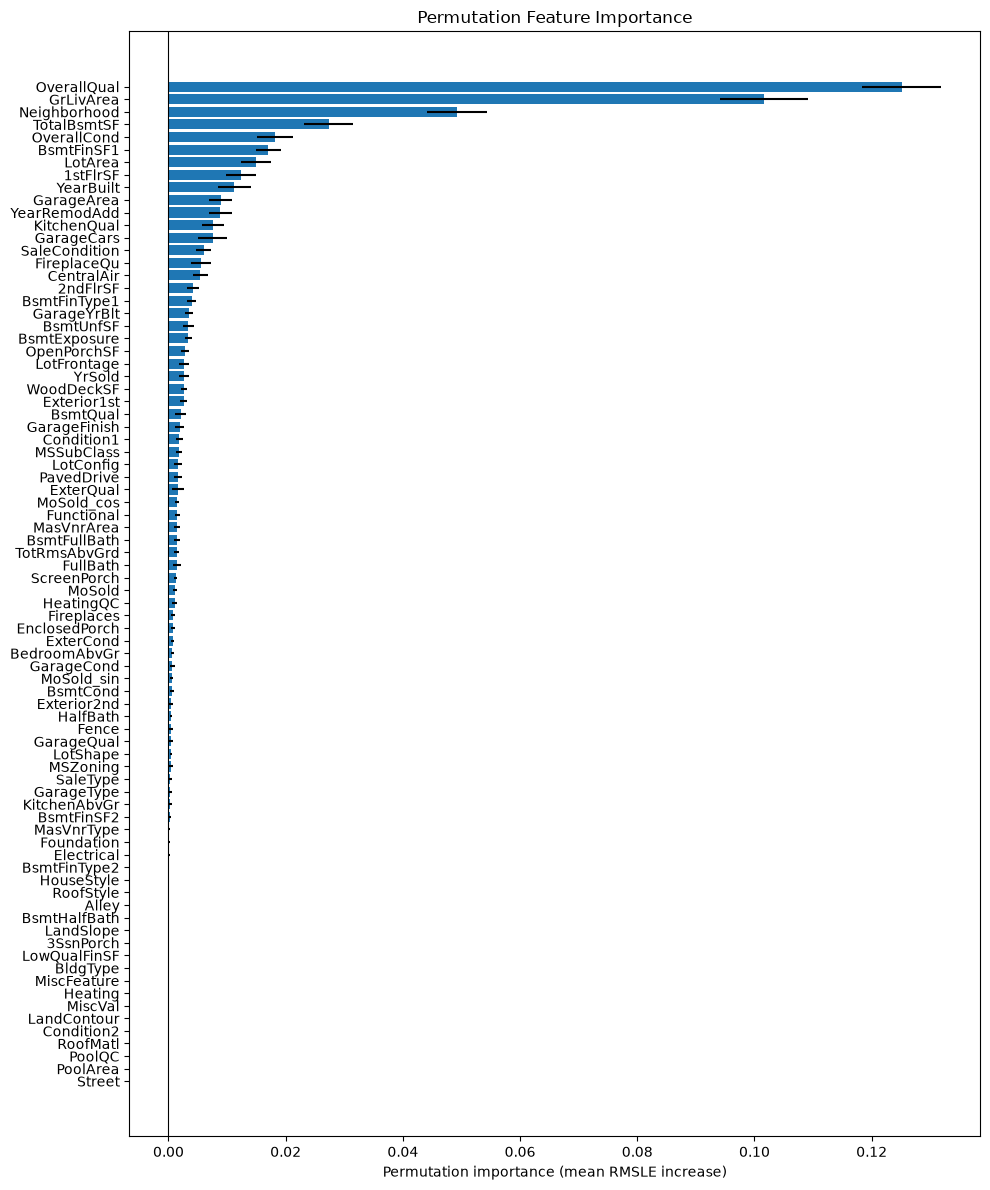

In [113]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, max(6, len(perm_result) * 0.15)))

ax.barh(
    perm_result.index[::-1],
    perm_result["mean_importance"][::-1],
    xerr=perm_result["std_importance"][::-1],
    color=[
        "tab:red" if v <= 0 else "tab:blue"
        for v in perm_result["mean_importance"][::-1]
    ],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Permutation importance (mean RMSLE increase)")
ax.set_title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics
# 5 фичей убраны


baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.11847


In [123]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures, 5 features less",
)

### true feature importance
trying to get better score by deleting noisy features

In [ ]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

models, oof, metrics, scores, importances = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
    calculate_importance=True,
    n_repeats=10,
)
metrics

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.11847


In [142]:
importances[:25]

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,importance_mean,importance_std
EnclosedPorch,-4.555909e-04,0.000194,3.822685e-04,0.000547,0.000284,0.000295,-0.000502,0.000122,0.000076,-1.123637e-04,...,-0.000090,-0.000405,0.000454,0.000729,-0.000019,-0.000143,-4.691074e-04,0.000490,9.931085e-05,0.000342
Exterior2nd,3.753486e-04,-0.000035,-2.800282e-04,-0.000089,0.000013,0.000037,0.000049,-0.000117,0.000059,2.965682e-04,...,-0.000115,0.000549,0.000244,-0.000013,0.000060,-0.000018,-1.378111e-04,0.000034,4.050751e-05,0.000189
GarageCond,1.903743e-03,-0.000169,-7.682031e-05,-0.000037,-0.000083,-0.000689,0.001545,-0.000230,-0.000254,-1.809088e-04,...,-0.000213,-0.000202,-0.000861,-0.000015,-0.000789,0.000231,1.672125e-03,-0.000418,3.635873e-05,0.000665
BedroomAbvGr,-1.065004e-04,-0.000208,1.444420e-03,0.000439,-0.000687,-0.000027,-0.000278,-0.000023,-0.000317,-4.147691e-04,...,0.000145,-0.000515,-0.000004,0.000284,-0.000169,-0.000246,-6.038137e-05,0.000044,3.148496e-05,0.000433
Electrical,-0.000000e+00,-0.000000,-0.000000e+00,-0.000205,-0.000000,-0.000000,0.000093,-0.000000,0.000263,-0.000000e+00,...,-0.000085,0.000208,0.000027,-0.000000,0.000030,-0.000003,6.550385e-05,-0.000003,2.384200e-05,0.000114
Foundation,4.327650e-04,-0.000012,3.184459e-05,0.000069,0.000059,0.000068,-0.000029,-0.000000,-0.000053,-0.000000e+00,...,-0.000037,-0.000119,-0.000102,0.000030,-0.000219,-0.000000,-2.639904e-05,-0.000055,2.216642e-05,0.000127
BsmtFinType2,-2.821412e-05,0.000043,-3.873210e-05,-0.000041,-0.000010,-0.000006,0.000222,-0.000008,0.000120,1.982673e-05,...,0.000027,0.000024,-0.000043,0.000019,0.000018,-0.000009,-3.597960e-06,0.000117,1.597466e-05,0.000062
LandSlope,3.648530e-06,0.000014,-1.287933e-05,-0.000010,-0.000009,0.000114,0.000006,-0.000000,0.000006,-0.000000e+00,...,0.000059,0.000250,-0.000028,-0.000000,-0.000013,0.000008,-0.000000e+00,-0.000000,1.482521e-05,0.000056
RoofStyle,-2.150282e-05,-0.000000,1.539022e-04,-0.000000,0.000017,-0.000000,-0.000012,0.000027,-0.000012,3.349720e-05,...,-0.000000,-0.000044,-0.000000,-0.000000,-0.000011,-0.000000,-0.000000e+00,0.000159,1.184621e-05,0.000042
Alley,4.470918e-05,-0.000063,1.740237e-05,0.000024,-0.000047,-0.000004,-0.000076,-0.000011,0.000002,-2.985734e-05,...,0.000018,-0.000024,-0.000000,0.000001,0.000002,-0.000007,7.981698e-06,-0.000088,8.172033e-06,0.000042


In [ ]:
# претенденты на удаление
importances[importances["importance_mean"] <= 0].index.to_list()

['EnclosedPorch',
 'Exterior2nd',
 'GarageCond',
 'BedroomAbvGr',
 'Electrical',
 'Foundation',
 'BsmtFinType2',
 'LandSlope',
 'RoofStyle',
 'Alley',
 'BsmtHalfBath',
 'GarageQual',
 'HouseStyle',
 'LowQualFinSF',
 'MiscVal',
 'LandContour',
 'Street',
 'Utilities',
 'Condition2',
 'PoolQC',
 'PoolArea',
 'RoofMatl']

In [144]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced


In [ ]:
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
)
metrics

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.037861,0.013322,0.119991,0.01287,0.117744


In [ ]:
importance_df

### extra check

In [31]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

In [32]:
new_rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed % 31)

In [35]:
models, oof, metrics, scores, importance_df = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=new_rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
    calculate_importance=True,
    perm_n_repeats=10,
)
metrics

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.037876,0.013941,0.119969,0.014396,0.117808


In [42]:
importance_df[importance_df["importance_mean"] <= 0].index.to_list()

['Alley',
 'Condition2',
 'LandContour',
 'Utilities',
 'LandSlope',
 'Street',
 'HouseStyle',
 'Exterior2nd',
 'Foundation',
 'GarageQual',
 'LowQualFinSF',
 'BsmtFinType2',
 'Electrical',
 'RoofMatl',
 'RoofStyle',
 'BedroomAbvGr',
 'BsmtHalfBath',
 'PoolQC',
 'PoolArea',
 'GarageCond',
 'EnclosedPorch',
 'MiscVal',
 'MiscFeature',
 'Heating',
 'MoSold']

### less features

In [43]:
import src.tests.tests1 as tests1

importlib.reload(tests1)
advanced = tests1.advanced

In [45]:
advanced.fit_transform(X_train).shape

(1458, 56)

In [44]:
new_rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed % 37)
models, oof, metrics, scores = cv_result(
    model=lgbm_search_model,
    X_train=X_train,
    y_train=y_train,
    y_strat=y_binned,
    cv_splitter=new_rskf,
    preprocessor=advanced,
    name="baseline with early stopping",
    use_early_stopping=True,
    early_stopping_callback=es_callback,
    # calculate_importance=True,
    # perm_n_repeats= 10
)
metrics

baseline with early stopping:   0%|          | 0/50 [00:00<?, ?fold/s]

,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
0,baseline with early stopping,0.038554,0.01616,0.120873,0.013886,0.118692


In [46]:
metrics_dict = metrics.iloc[0].to_dict()
log_fe_experiment(
    metrics=metrics_dict,
    note="BWES + clean data + new lot frontage strategy + MonthFeatures + 25 features less",
)

In [47]:
log_file_path = Path(cfg.paths.logs) / "fe_experiments.log"
df = pd.read_json(log_file_path, lines=True)

normalized_data = pd.json_normalize(df["metrics"])
df = pd.concat([df.drop(columns=["metrics"]), normalized_data], axis=1)


with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(df.sort_values(by=["OOF_rmsle"], ascending=True))

,timestamp,note,model,TRAIN_rmsle_MEAN,TRAIN_rmsle_STD,VAL_rmsle_MEAN,VAL_rmsle_STD,OOF_rmsle
13,2026-09-18 14:30:16,BWES + clean data + new lot frontage strategy + MonthFeatures + 22 features less,baseline with early stopping,0.037876,0.013941,0.119969,0.014396,0.117808
7,2026-09-17 23:18:09,BWES + clean data + new lot frontage strategy + MonthFeatures + Flags,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.118470
12,2026-09-18 00:51:50,"BWES + clean data + new lot frontage strategy + MonthFeatures, 5 features less",baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.118470
4,2026-09-17 18:35:15,BWES + clean data + new lot frontage strategy + MonthFeatures,baseline with early stopping,0.040034,0.015401,0.120703,0.013265,0.118470
3,2026-09-17 18:16:37,BWES + clean data + new lot frontage strategy,baseline with early stopping,0.039861,0.014456,0.120734,0.013300,0.118564
5,2026-09-17 23:02:59,BWES + clean data + new lot frontage strategy + MonthFeatures + YearFeatures,baseline with early stopping,0.038167,0.013968,0.120806,0.012980,0.118629
14,2026-09-18 18:12:08,BWES + clean data + new lot frontage strategy + MonthFeatures + 25 features less,baseline with early stopping,0.038554,0.016160,0.120873,0.013886,0.118692
11,2026-09-18 00:07:50,BWES + clean data + new lot frontage strategy + MonthFeatures + AreaPerCar,baseline with early stopping,0.040480,0.012978,0.120832,0.013352,0.118716
2,2026-09-17 17:55:42,BWES + clean data,baseline with early stopping,0.040583,0.014454,0.120983,0.013182,0.118760
10,2026-09-17 23:51:52,BWES + clean data + new lot frontage strategy + MonthFeatures + AgeNewVsLegacy,baseline with early stopping,0.042537,0.011680,0.121148,0.013491,0.119090


### Итог:
Лучший скор достигается BWES + clean data + new lot frontage strategy + MonthFeatures + удалиение ["EnclosedPorch", "Exterior2nd", "GarageCond", "BedroomAbvGr", "Electrical", "Foundation", "BsmtFinType2", "LandSlope", "RoofStyle", "Alley", "BsmtHalfBath", "GarageQual", "HouseStyle", "LowQualFinSF", "MiscVal", "LandContour", "Street", "Utilities", "Condition2", "PoolQC", "PoolArea", "RoofMatl"]